Importamos librerias

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from collections import Counter

In [85]:
pd.set_option('display.max_columns', None)

In [86]:
data  = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/TenisCSV.csv'

In [87]:
df = pd.read_csv(data)

Verificamos: tiene 16085 registros

In [88]:
df.shape

(16085, 37)

Las primeras 5 filas se ven asi

In [89]:
df.head(5)

,Unnamed: 0,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,B365W,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL
0,0,33.0,Paris,French Open,24/05/15,Grand Slam,Outdoor,Clay,1st Round,5.0,Bautista R.,Mayer F.,20.0,527.0,1750.0,63.0,6.0,3.0,6.0,1.0,6.0,3.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,1.11,6.50,1.13,7.41,1.15,7.54,1.12,6.12
1,1,33.0,Paris,French Open,24/05/15,Grand Slam,Outdoor,Clay,1st Round,5.0,Dzumhur D.,Youzhny M.,88.0,68.0,601.0,720.0,6.0,2.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Retired,2.25,1.57,2.27,1.71,2.30,1.75,2.21,1.64
2,2,33.0,Paris,French Open,24/05/15,Grand Slam,Outdoor,Clay,1st Round,5.0,Kohlschreiber P.,Soeda G.,28.0,92.0,1285.0,575.0,6.0,1.0,6.0,0.0,6.0,2.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,1.04,13.00,1.04,16.00,1.06,16.00,1.04,11.54
3,3,33.0,Paris,French Open,24/05/15,Grand Slam,Outdoor,Clay,1st Round,5.0,Rosol L.,Ymer E.,43.0,175.0,1035.0,283.0,6.0,2.0,7.0,6.0,6.0,3.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,1.44,2.62,1.42,3.11,1.50,3.11,1.45,2.70
4,4,33.0,Paris,French Open,24/05/15,Grand Slam,Outdoor,Clay,1st Round,5.0,Baghdatis M.,Karlovic I.,59.0,25.0,832.0,1330.0,7.0,6.0,6.0,4.0,6.0,4.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,2.00,1.72,2.11,1.81,2.11,1.85,2.00,1.78


Sacamos la columna Unnamed: 0 que tiene los indices guardados del to_csv del otro Colab

In [90]:
df = df.drop(columns=['Unnamed: 0'])

### Valores Faltantes

Eliminamos filas que son todas nulas

In [91]:
df = df.dropna(how='all')

Vemos cantidad de nulos por columna

In [92]:
df.isna().sum().to_frame().T

,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,B365W,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL
0,0,0,0,0,0,0,0,0,0,1,1,4,27,4,27,114,112,237,237,6969,6969,13253,13253,15020,15020,115,117,1,45,44,124,124,11,11,11,11


Eliminamos filas que tienen nulo al Winner o Loser

In [93]:
df = df.dropna(subset=['Winner', 'Loser'])

Las distribuciones de B365 odds y Average Odds no son iguales

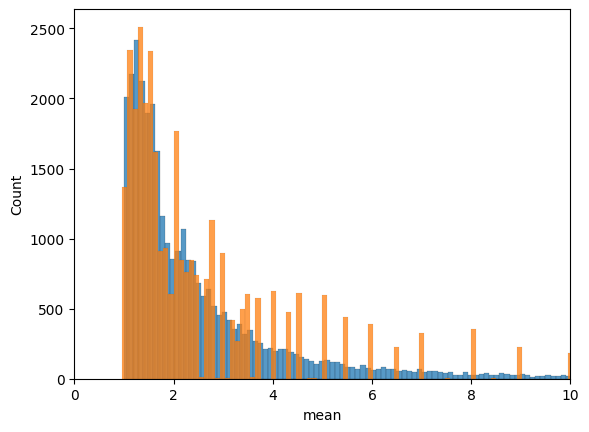

TEST 1 - KS2
Con p-valor 2.1996571606898886e-08, podemos rechazar la hipótesis nula de que las distribuciones son iguales
TEST 2 KS2- REDUCIDO
Con p-valor 2.0254178514804353e-09, podemos rechazar la hipótesis nula de que las distribuciones son iguales
TEST 3 - Mann-Whitney U
Con p-valor 0.2749472136016379, se retiene la hipótesis nula de que las distribuciones y medianas son iguales
TEST 4 - Correlacion
p-Valor Pearson: 0.0
p-Valor Spearman: 0.0


In [94]:
df_copia = df.copy()
df_copia = df_copia.dropna(subset=['AvgW', 'AvgL', 'B365W', 'B365L'])
mean_odds = pd.concat([df_copia['AvgW'], df_copia['AvgL']], axis=0)
b365_odds = pd.concat([df_copia['B365W'], df_copia['B365L']], axis=0)
df_odds = pd.concat([mean_odds, b365_odds], axis=1, keys=['mean','b365'])
sns.histplot(data=df_odds['mean'])
sns.histplot(data=df_odds['b365'])
plt.xlim(0, 10)
plt.show()

print('TEST 1 - KS2')
ks2 = stats.ks_2samp(df_odds['mean'],df_odds['b365'])
if ks2.pvalue<0.05:
  print(f'Con p-valor {ks2.pvalue}, podemos rechazar la hipótesis nula de que las distribuciones son iguales')
else:
  print(f'Con p-valor {ks2.pvalue}, se retiene la hipótesis nula de que las distribuciones son iguales')

print('TEST 2 KS2- REDUCIDO')
odds_reduced = df_odds.copy()
odds_reduced = odds_reduced[(odds_reduced['mean'] < 5) & (odds_reduced['b365'] < 5)]
ks2_2 = stats.ks_2samp(odds_reduced['mean'],odds_reduced['b365'])
if ks2_2.pvalue<0.05:
  print(f'Con p-valor {ks2_2.pvalue}, podemos rechazar la hipótesis nula de que las distribuciones son iguales')
else:
  print(f'Con p-valor {ks2_2.pvalue}, se retiene la hipótesis nula de que las distribuciones son iguales')

print('TEST 3 - Mann-Whitney U')
u_stat, p_value_medianas = stats.mannwhitneyu(df_odds['mean'],df_odds['b365'], alternative='two-sided')
if p_value_medianas<0.05:
  print(f'Con p-valor {p_value_medianas}, podemos rechazar la hipótesis nula de que las distribuciones y medianas son iguales')
else:
  print(f'Con p-valor {p_value_medianas}, se retiene la hipótesis nula de que las distribuciones y medianas son iguales')

print('TEST 4 - Correlacion')
pears=stats.pearsonr(df_odds['mean'],df_odds['b365'])
print("p-Valor Pearson: "+str(pears.pvalue))
spear=stats.spearmanr(df_odds['mean'],df_odds['b365'])
print("p-Valor Spearman: "+str(spear.pvalue))

Hay un solo partido donde no tenemos las odds promedio pero si las de B365.

Imputamos por las de B365

In [95]:
mask_imputation = (df['B365W'].isna() == False) & (df['AvgW'].isna() == True)
df.loc[mask_imputation, 'AvgW'] = df.loc[mask_imputation, 'B365W']
df.loc[mask_imputation, 'AvgL'] = df.loc[mask_imputation, 'B365L']

Hay un solo partido donde falta MaxW y MaxL, que es el mismo que arriba.
Imputamos por el maximo entre las 2 odds que tenemos (Bet365 y PS)

In [96]:
mask_imputation = (df['MaxW'].isna() == True)
valores = df.loc[mask_imputation, ['B365W', 'B365L', 'PSW', 'PSL']]
df.loc[mask_imputation, 'MaxW'] = valores.max(axis=1)
df.loc[mask_imputation, 'MaxL'] = valores.min(axis=1)

Si faltan las odds de B365 y las Avg, entonces eliminamos esas filas. Son solo 9 partidos

In [97]:
df = df.loc[~((df['B365W'].isna() == True) & (df['AvgW'].isna() == True))]

Si faltan las odds de B365, pero no las promedio, como son solo 35 partidos y no quiero tirar esos datos, imputo por el Avg

In [98]:
mask_imputation = (df['B365W'].isna() == True) & (df['AvgW'].isna() == False)
df.loc[mask_imputation, 'B365W'] = df.loc[mask_imputation, 'AvgW']
df.loc[mask_imputation, 'B365L'] = df.loc[mask_imputation, 'AvgL']

Los partidos que no tienen de comentario Completed, los ponemos como No Completed. El que dice Sched debe ser un error, lo pasamos a completed

In [99]:
df.loc[df['Comment'] == 'Sched', 'Comment'] = 'Completed'
df.loc[df['Comment'] != 'Completed', 'Comment'] = 'Not Completed'

Los nulos en W1, L1, W2 y L2 que son la cantidad de sets del ganador y perdedor, estan completos cuando corresponde, que es cuando el partido termino y esta en estado 'Completed'

In [100]:
partidos_completed = df[df['Comment'] == 'Completed']
jugadores = ['W', 'L']
for jugador in jugadores:
  for n_set in range(1,3):
    cantidad_nulos_raros = partidos_completed[f'{jugador}{n_set}'].isna().sum()
    print(f'La columna {jugador}{n_set} tiene {cantidad_nulos_raros} nulos que no deberian tener')

La columna W1 tiene 0 nulos que no deberian tener
La columna W2 tiene 0 nulos que no deberian tener
La columna L1 tiene 0 nulos que no deberian tener
La columna L2 tiene 0 nulos que no deberian tener


In [101]:
df[(df['Comment'] == 'Completed') & (df['L1'].isna() == True)]

,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,B365W,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL


In [102]:
df[(df['Comment'] == 'Completed') & (df['W1'].isna() == True)]

,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,B365W,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL


Los nulos en Wsets y Lsets ocurren, salvo uno, todos en partidos que no fueron completados. A ese que no los tiene, lo rellenamos manualmente, porque parece haber un problema con los datos. También corregimos ese dato.

In [103]:
mask_imputation = (df['Lsets'].isna() == True) & (df['Comment'] == 'Completed')
df.loc[mask_imputation, 'Wsets'] = 2
df.loc[mask_imputation, 'Lsets'] = 0
df.loc[mask_imputation, 'L1'] = 6

Eliminamos la columna de Pinnacles Sports odds, porque ya tenemos las de B365 y otras, y son 114 registros que no seria muy logico imputar, y partidos que no vamos a borrar.

In [104]:
df = df.drop(columns=['PSW','PSL'])

Rellenamos los datos de sets que son nulos como 0

In [105]:
df['Wsets'] = df['Wsets'].fillna(0)
df['Lsets'] = df['Lsets'].fillna(0)

df['W1'] = df['W1'].fillna(0)
df['L1'] = df['L1'].fillna(0)

df['W2'] = df['W2'].fillna(0)
df['L2'] = df['L2'].fillna(0)

df['W3'] = df['W3'].fillna(0)
df['L3'] = df['L3'].fillna(0)

df['W4'] = df['W4'].fillna(0)
df['L4'] = df['L4'].fillna(0)

df['W5'] = df['W5'].fillna(0)
df['L5'] = df['L5'].fillna(0)

Cambiamos la variable Date a tipo de dato fecha y ordenamos por fecha el dataset

In [106]:
df['Fecha'] = df['Date'].apply(lambda x: str(x.split('/')[0]) + '/' + str(x.split('/')[1]) + '/20' + str(x.split('/')[2]) if len(x.split('/')[2]) == 2 else x)
df['Fecha'] = pd.to_datetime(df['Fecha'], format = '%d/%m/%Y')

In [107]:
df = df.sort_values(by='Fecha', ascending=True)

Solo nos queda imputar los rankings y puntos de algunos jugadores que quedaron sin. Vamos a rellenar ese nulo con el ultimo ranking del jugador, asi no perdemos ese partido. Si el jugador no tiene un partido previo con ranking, imputamos por el siguiente partido a ese encuentro donde sí haya registrado ranking.

Si nunca tuvo ranking dentro del dataset, le asignamos 1000 de ranking.

In [108]:
rank_by_date = pd.concat([df[['Winner', 'WRank','Fecha']].rename(columns={'Winner':'Player','WRank':'Rank'}),
                          df[['Loser', 'LRank','Fecha']].rename(columns={'Loser':'Player','LRank':'Rank'})],
                          axis=0).sort_values(by='Fecha', ascending=True)

pts_by_date = pd.concat([df[['Winner', 'WPts','Fecha']].rename(columns={'Winner':'Player','WPts':'Pts'}),
                          df[['Loser', 'LPts','Fecha']].rename(columns={'Loser':'Player','LPts':'Pts'})],
                          axis=0).sort_values(by='Fecha', ascending=True)

In [109]:
def imputar_rank(rank_by_date, player, fecha, rankImputacion = 1000):
  # Filter for player and dates before the current match
  df_player = rank_by_date[(rank_by_date['Player'] == player) & (rank_by_date['Fecha'] <= fecha)]
  # Drop rows where 'Rank' is NaN to ensure we get a valid rank
  df_player = df_player.dropna(subset=['Rank'])
  if len(df_player) > 0:
    return df_player['Rank'].iloc[-1]
  else:   # Si no tiene partidos anteriores dentro de la base, les imputamos el siguiente valor que aparezca
    df_player = rank_by_date[(rank_by_date['Player'] == player) & (rank_by_date['Fecha'] >= fecha)]
    df_player = df_player.dropna(subset=['Rank'])
    return df_player['Rank'].iloc[0] if len(df_player) > 0 else rankImputacion # Les imputamos un ranking ATP si no tienen ranking previo

def imputar_pts(pts_by_date, player, fecha, ptsImputados = 1):
  # Filter for player and dates before the current match
  df_player = pts_by_date[(pts_by_date['Player'] == player) & (pts_by_date['Fecha'] <= fecha)]
  # Drop rows where 'Pts' is NaN to ensure we get a valid Pts
  df_player = df_player.dropna(subset=['Pts'])
  if len(df_player) > 0:
    return df_player['Pts'].iloc[-1]
  else:   # Si no tiene partidos anteriores dentro de la base, les imputamos el siguiente valor que aparezca
    df_player = pts_by_date[(pts_by_date['Player'] == player) & (pts_by_date['Fecha'] >= fecha)]
    df_player = df_player.dropna(subset=['Pts'])
    return df_player['Pts'].iloc[0] if len(df_player) > 0 else ptsImputados # Les imputamos los puntos ATP si no tiene puntos previo


# Impute LRank
mask_lrank_na = df['LRank'].isna()
df.loc[mask_lrank_na, 'LRank'] = df[mask_lrank_na].apply(lambda x: imputar_rank(rank_by_date, x['Loser'], x['Fecha']), axis=1)

# Impute LPts
mask_lpts_na = df['LPts'].isna()
df.loc[mask_lpts_na, 'LPts'] = df[mask_lpts_na].apply(lambda x: imputar_pts(pts_by_date, x['Loser'], x['Fecha']), axis=1)

# Impute WRank
mask_wrank_na = df['WRank'].isna()
df.loc[mask_wrank_na, 'WRank'] = df[mask_wrank_na].apply(lambda x: imputar_rank(rank_by_date, x['Winner'], x['Fecha'], 700), axis=1)

# Impute WPts
mask_wpts_na = df['WPts'].isna()
df.loc[mask_wpts_na, 'WPts'] = df[mask_wpts_na].apply(lambda x: imputar_pts(pts_by_date, x['Loser'], x['Fecha'], 20), axis=1)

Volvemos a ver los nulos. Resolvimos todos

In [110]:
df.isna().sum().to_frame().T

,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,B365W,B365L,MaxW,MaxL,AvgW,AvgL,Fecha
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Cambio Player Column

Cambiamos las columnas de Winner y Loser porque sino nuestro modelo va a poder mirara a esas y definir el ganador automaticamente con una accuracy de 100%, porque el ganador estaria siempre en la misma columa.

Creamos las columnas de Jugador A y Jugador B en base a un mask de valores aleatorios.

Como ya usamos el ranking ATP como feature, no usaremos el siguiente criterio, pero es una opcion valida si prescindimos de la feature ranking:

El Jugador A, y todas sus estadisticas, perteneceran al jugador mejor rankeado de los dos. El otro sera el Jugador B.

La logica por la que podemos realizar esta operacion es la siguiente:
- Mi columna de Jugador A la voy a generar evaluando fila por fila: si el ranking del Winner es mejor (menor) al ranking del Loser, en Jugador A va a ir el nombre del Winner. Si eso no ocurre y el perdedor tiene mejor ranking, en Jugador A va a ir el nombre del Loser.
- Hacemos lo mismo para generar la columna del Jugador B y repetimos para todas las varaibles que haya que hacer la diferenciacion

In [111]:
np.random.seed(42)

mask = np.random.rand(len(df)) > 0.5
df["playerA"] = np.where(mask, df["Winner"], df["Loser"])
df["playerB"] = np.where(mask, df["Loser"], df["Winner"])

df['rankA'] = np.where(mask, df["WRank"], df["LRank"])
df['rankB'] = np.where(mask, df["LRank"], df["WRank"])

df['PtsA'] = np.where(mask, df["WPts"], df["LPts"])
df['PtsB'] = np.where(mask, df["LPts"], df["WPts"])

df['B365A'] = np.where(mask, df["B365W"], df["B365L"])
df['B365B'] = np.where(mask, df["B365L"], df["B365W"])

df['MaxA'] = np.where(mask, df["MaxW"], df["MaxL"])
df['MaxB'] = np.where(mask, df["MaxL"], df["MaxW"])

df['AvgA'] = np.where(mask, df["AvgW"], df["AvgL"])
df['AvgB'] = np.where(mask, df["AvgL"], df["AvgW"])

df['A1'] = np.where(mask, df["W1"], df["L1"])
df['B1'] = np.where(mask, df["L1"], df["W1"])
df['A2'] = np.where(mask, df["W2"], df["L2"])
df['B2'] = np.where(mask, df["L2"], df["W2"])
df['A3'] = np.where(mask, df["W3"], df["L3"])
df['B3'] = np.where(mask, df["L3"], df["W3"])
df['A4'] = np.where(mask, df["W4"], df["L4"])
df['B4'] = np.where(mask, df["L4"], df["W4"])
df['A5'] = np.where(mask, df["W5"], df["L5"])
df['B5'] = np.where(mask, df["L5"], df["W5"])

df['setsA'] = np.where(mask, df["Wsets"], df["Lsets"])
df['setsB'] = np.where(mask, df["Lsets"], df["Wsets"])

# Creamos variable target: gana el jugador A (entonces 1), gana el jugador B (entonces 0)
df['target'] = (df["playerA"] == df["Winner"]).astype(int)

In [112]:
mask

array([False,  True,  True, ..., False, False, False])

In [113]:
# Comprobamos que el dataset quedo balanceado
Counter(mask)

Counter({np.False_: 8124, np.True_: 7937})

Alternativa:

In [114]:
# ALTERNATIVA

# # Creamos columna de Jugador A (mejor rankeado) y  Jugador B (peor rankeado)
# df['playerA'] = np.where(df["WRank"] < df["LRank"], df["Winner"], df["Loser"])
# df['playerB'] = np.where(df["WRank"] < df["LRank"], df["Loser"], df["Winner"])

# # Creamos columnas de Ranking, Pts ATP, Sets y Odds segun Jugador A o Jugador B
# df['rankA'] = np.where(df["WRank"] < df["LRank"], df["WRank"], df["LRank"])
# df['rankB'] = np.where(df["WRank"] < df["LRank"], df["LRank"], df["WRank"])

# df['PtsA'] = np.where(df["WRank"] < df["LRank"], df["WPts"], df["LPts"])
# df['PtsB'] = np.where(df["WRank"] < df["LRank"], df["LPts"], df["WPts"])

# df['B365A'] = np.where(df["WRank"] < df["LRank"], df["B365W"], df["B365L"])
# df['B365B'] = np.where(df["WRank"] < df["LRank"], df["B365L"], df["B365W"])

# df['MaxA'] = np.where(df["WRank"] < df["LRank"], df["MaxW"], df["MaxL"])
# df['MaxB'] = np.where(df["WRank"] < df["LRank"], df["MaxL"], df["MaxW"])

# df['AvgA'] = np.where(df["WRank"] < df["LRank"], df["AvgW"], df["AvgL"])
# df['AvgB'] = np.where(df["WRank"] < df["LRank"], df["AvgL"], df["AvgW"])

Comprobamos que todo se haya llevado a cabo como fue esperado. Miramos algunas columnas y verificamos que si el Winner fue a Jugador A, el target sea 0 y el ranking de Jugador A coincida con el del Winner, por ejemplo.


In [115]:
df[['Winner','Loser','playerA','playerB','WRank','LRank','rankA', 'rankB','target']]

,Winner,Loser,playerA,playerB,WRank,LRank,rankA,rankB,target
11805,Gasquet R.,Andujar P.,Andujar P.,Gasquet R.,26.0,41.0,41.0,26.0,0
11804,Dodig I.,Safwat M.,Dodig I.,Safwat M.,89.0,289.0,89.0,289.0,1
11807,Verdasco F.,Gabashvili T.,Verdasco F.,Gabashvili T.,33.0,66.0,33.0,66.0,1
11808,Karlovic I.,Rosol L.,Karlovic I.,Rosol L.,27.0,30.0,27.0,30.0,1
11803,Bolelli S.,Becker B.,Becker B.,Bolelli S.,52.0,40.0,40.0,52.0,0
...,...,...,...,...,...,...,...,...,...
10061,Sinner J.,Shelton B.,Shelton B.,Sinner J.,2.0,7.0,7.0,2.0,0
10062,Zverev A.,Medvedev D.,Zverev A.,Medvedev D.,3.0,13.0,3.0,13.0,1
10063,Auger-Aliassime F.,Bublik A.,Bublik A.,Auger-Aliassime F.,10.0,16.0,16.0,10.0,0
10064,Sinner J.,Zverev A.,Zverev A.,Sinner J.,2.0,3.0,3.0,2.0,0


In [116]:
df[['W1', 'L1', 'W2', 'L2', 'A1', 'B1', 'A2', 'B2','target']].head(2)

,W1,L1,W2,L2,A1,B1,A2,B2,target
11805,6.0,3.0,7.0,5.0,3.0,6.0,5.0,7.0,0
11804,6.0,3.0,6.0,1.0,6.0,3.0,6.0,1.0,1


In [117]:
# df.to_csv('df_tenis_columns_OK.csv')